In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [23]:
# case_2 {'tau': 0.05, 'sigma': 1.4142135623730951}
# case_5 {'tau': 0.5, 'sigma': 1.4142135623730951}
# case_8 {'tau': 2.0, 'sigma': 1.4142135623730951}

In [24]:
# Load data
data2 = np.load("raw_case_2.npz")
eta2 = data2["all_eta"][49]     # shape: (n_runs, N) # using one realization
tau2 = data2["tau"]

data5 = np.load("raw_case_5.npz")
eta5 = data5["all_eta"][0]     
tau5 = data5["tau"]

data8 = np.load("raw_case_8.npz")
eta8 = data8["all_eta"][0]     
tau8 = data8["tau"]

time = data2["time"]

In [25]:
dt = time[1] - time[0]

In [26]:
# ---- ACF function ----
def autocorr(x):
    x = x - np.mean(x)
    result = np.correlate(x, x, mode='full')
    result = result[result.size // 2:]
    return result / result[0]

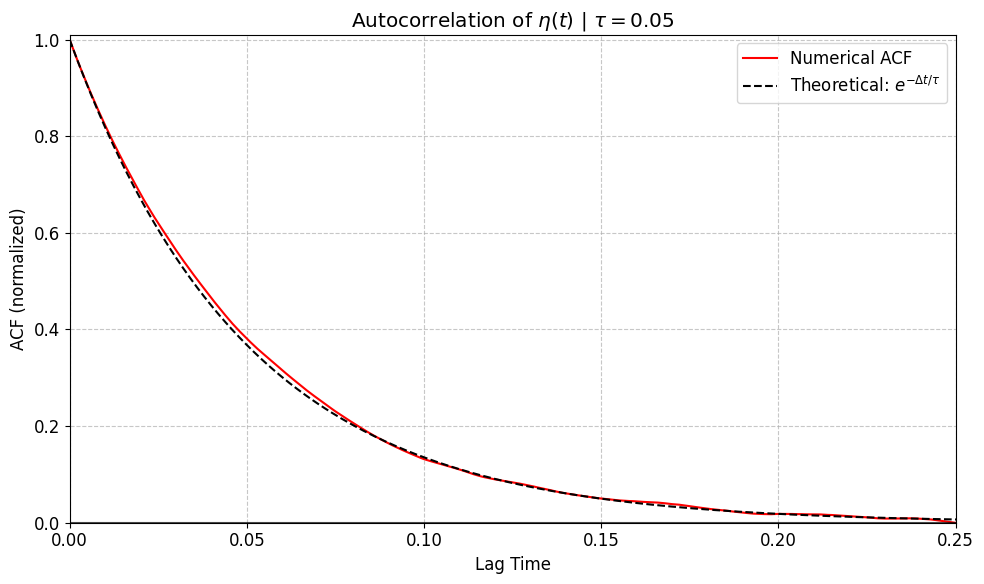

In [27]:
# dt = np.mean(np.diff(time))
C_sim2 = np.array(autocorr(eta2))
# ---- Time axis ----
t = np.arange(len(C_sim2)) * dt
# ---- Theory ----
C_theory2 = np.exp(-t / tau2)
# ---- Plot ----
plt.plot(t, C_sim2, color='r', label="Numerical ACF")
plt.plot(t, C_theory2, color='k', ls='--', label="Theoretical: $e^{{-\\Delta t/\\tau}}$")
plt.axhline(0, color='k', ls='-', alpha=0.7)
plt.xlim(0, 5*tau2)
plt.ylim(0, 1.01)
plt.xlabel("Lag Time")
plt.ylabel("ACF (normalized)")
plt.title(r"Autocorrelation of $\eta(t)$ | $\tau=0.05$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("acf_tau0.05.png", dpi=600, bbox_inches="tight")
plt.show()

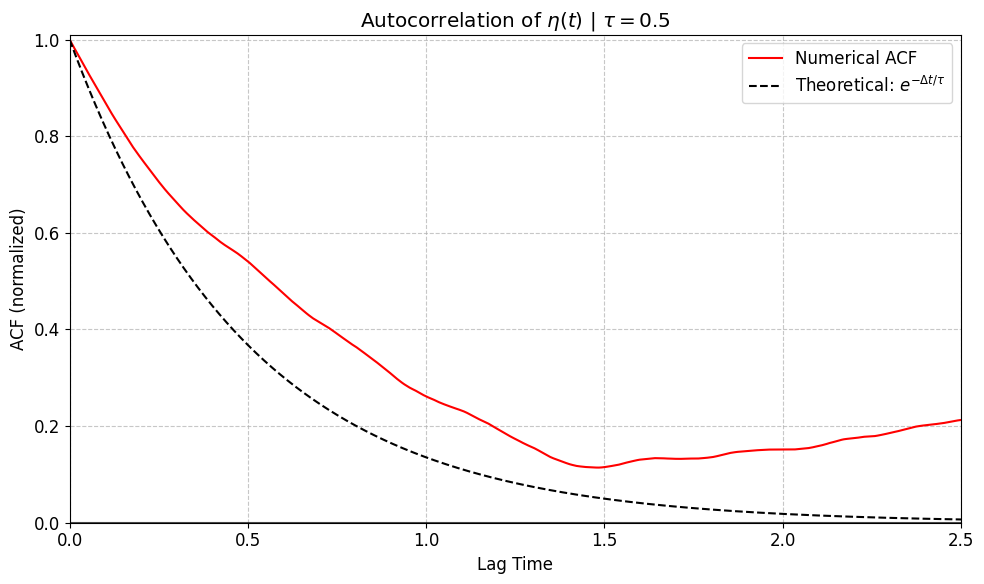

In [28]:
C_sim5 = np.array(autocorr(eta5))
t = np.arange(len(C_sim5)) * dt
C_theory5 = np.exp(-t / tau5)
# ---- Plot ----
plt.plot(t, C_sim5, color='r', label="Numerical ACF")
plt.plot(t, C_theory5, color='k', ls='--', label="Theoretical: $e^{{-\\Delta t/\\tau}}$")
plt.axhline(0, color='k', ls='-', alpha=0.7)
plt.xlim(0, 5*tau5)
plt.ylim(0, 1.01)
plt.xlabel("Lag Time")
plt.ylabel("ACF (normalized)")
plt.title(r"Autocorrelation of $\eta(t)$ | $\tau=0.5$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("acf_tau0.5.png", dpi=600, bbox_inches="tight")
plt.show()

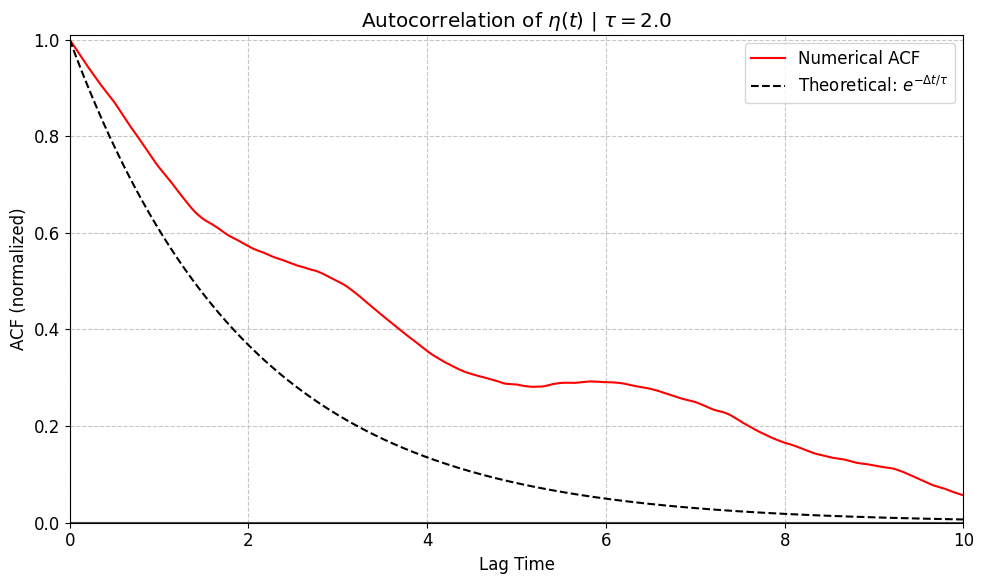

In [29]:
C_sim8 = np.array(autocorr(eta8))
t = np.arange(len(C_sim8)) * dt
C_theory8 = np.exp(-t / tau8)
# ---- Plot ----
plt.plot(t, C_sim8, color='r', label="Numerical ACF")
plt.plot(t, C_theory8, color='k', ls='--', label="Theoretical: $e^{{-\\Delta t/\\tau}}$")
plt.axhline(0, color='k', ls='-', alpha=0.7)
plt.xlim(0, 5*tau8)
plt.ylim(0, 1.01)
plt.xlabel("Lag Time")
plt.ylabel("ACF (normalized)")
plt.title(r"Autocorrelation of $\eta(t)$ | $\tau=2.0$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("acf_tau2.0.png", dpi=600, bbox_inches="tight")
plt.show()

In [30]:
# dt = time[1] - time[0]
# # ---- ACF function ----
# def autocorr(x):
#     x = x - np.mean(x)
#     result = np.correlate(x, x, mode='full')
#     result = result[result.size // 2:]
#     return result / result[0]

# # ---- Compute ensemble ACF ----
# # C_all = np.array([autocorr(run) for run in eta_runs])
# C_all = np.array(autocorr(eta))
# # C_avg = np.mean(C_all, axis=0)

# # ---- Time axis ----
# t = np.arange(len(C_all)) * dt

# # ---- Theory ----
# C_theory = np.exp(-t / tau)
# # ---- Plot ----
# plt.plot(t, C_all, color='r', label="Simulation")
# plt.plot(t, C_theory, color='k', ls='--', label="Theory")
# plt.axhline(0, color='k', ls='-', alpha=0.7)
# plt.xlim(-0.01, 5*tau)
# plt.xlabel("Lag Time")
# plt.ylabel("ACF (normalized)")
# plt.title(r"Autocorrelation of $\eta(t)$")
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()
# plt.tight_layout()
# # plt.savefig("acf.png", dpi=600, bbox_inches="tight")
# plt.show()